# Main Figure 2: AGIST benchmark

Calculate the model outputs and draw the numerical panels a–e. Start with the
downloaded observations, trained models and generator references, then run
the cells in order. No finished panel image is used as a plotting input.

| Panel | Calculation | Trained model |
| --- | --- | --- |
| a | Four observed spatial snapshots | None |
| b | Velocity and its displayed projection | Released six-stage model |
| c | T0 attention and spatial flow | Original Figure 2 attention model (`1214`) |
| d | Growth compared with the generator | Released six-stage model |
| e | Ten seeded populations and Wasserstein-2 distances | Released six-stage model |

The attention model is supplied separately because panel c retains the original
attention analysis. The revised growth comparison uses the released model,
giving Pearson r = 0.9553 (0.96 to two decimal places).

Run these cells with the CytoBridge code folder available. The AGIST download
provides observations, models, edge predictors and both generator arrays.
Choose a new `CYTOBRIDGE_RUN_LABEL` for a new simulation.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

import CytoBridge as cb
from IPython.display import Image, display

project = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")).resolve()
device = os.environ.get("CYTOBRIDGE_DEVICE", "cuda")
run_name = os.environ.get("CYTOBRIDGE_RUN_LABEL", "reader_run")
repo = Path(cb.__file__).resolve().parents[1]

def run(module, *arguments):
    subprocess.run([sys.executable, "-m", module, *map(str, arguments)],
                   cwd=repo, check=True)

agist_root = Path(os.environ.get("CYTOBRIDGE_AGIST_DATA", project / "data/agist"))
if not (agist_root / "model/model_final").is_file():
    cb.datasets.download("agist", destination=project)
figure2_root = Path(os.environ.get("CYTOBRIDGE_AGIST_FIGURE2", agist_root / "figure2"))
if not (figure2_root / "reference/g_values.npy").is_file():
    cb.datasets.download("agist", destination=project, kind="agist_figure2_inputs.zip")
output = project / "outputs" / ("main_figure_2_" + run_name)
output.mkdir(parents=True, exist_ok=False)
figures = output / "figures"

def show_calculated(path, width=720):
    if Path(path).suffix == ".pdf":
        import pymupdf
        with pymupdf.open(path) as document:
            display(Image(data=document[0].get_pixmap(matrix=pymupdf.Matrix(1.5, 1.5)).tobytes("png"), width=width))
    else:
        display(Image(filename=str(path), width=width))

## a. Draw the four simulated snapshots

The original CSV already contains the generator's four sampled populations.
Plot the spatial coordinates, with every second cell displayed as in the
original plotting code. The upper brain/embryo illustration is a hand-drawn
schematic and does not require model output.

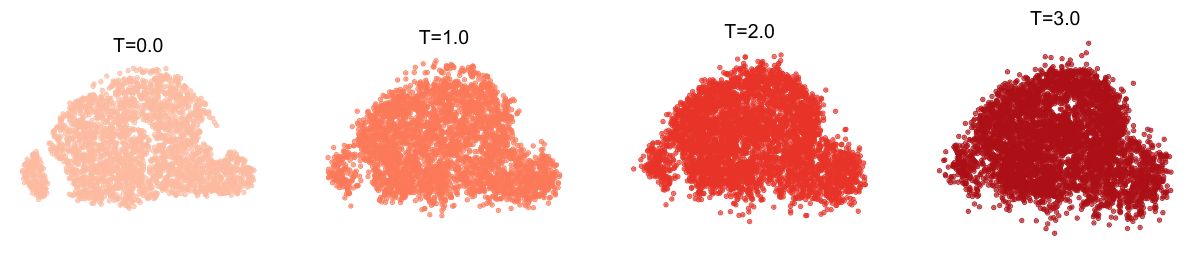

In [2]:
import pandas as pd
from reproduction.agist.main_figure import draw_observed_snapshots

observed = pd.read_csv(agist_root / "mouse_brain_simulation.csv")
snapshot_pdf = draw_observed_snapshots(observed, figures)
show_calculated(snapshot_pdf)

## b. Evaluate the velocity and calculate its displayed projection

Evaluate intrinsic drift, interaction and score gradient on the observed
cells. Sum them and compare with the saved generator fields. The original
display uses the same seed-0 30% sample for prediction and reference,
30-neighbor graphs, then scVelo velocity projection. The physical plot uses
T=0; the gene plot uses all times and the first two gene-state coordinates.
The `X_umap` name in scVelo is only a display key here, not a fitted UMAP.

/data/cytobridge/projects/CytoBridge-ST-1104/envs/arista-api/lib/python3.10/site-packages/torch/autograd/graph.py:979: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:408.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


computing velocity graph (using 4/160 cores)


    finished (0:00:08) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding


    finished (0:00:01) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


computing velocity graph (using 4/160 cores)


...

computing velocity graph (using 4/160 cores)


    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


computing velocity graph (using 4/160 cores)


    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


gene


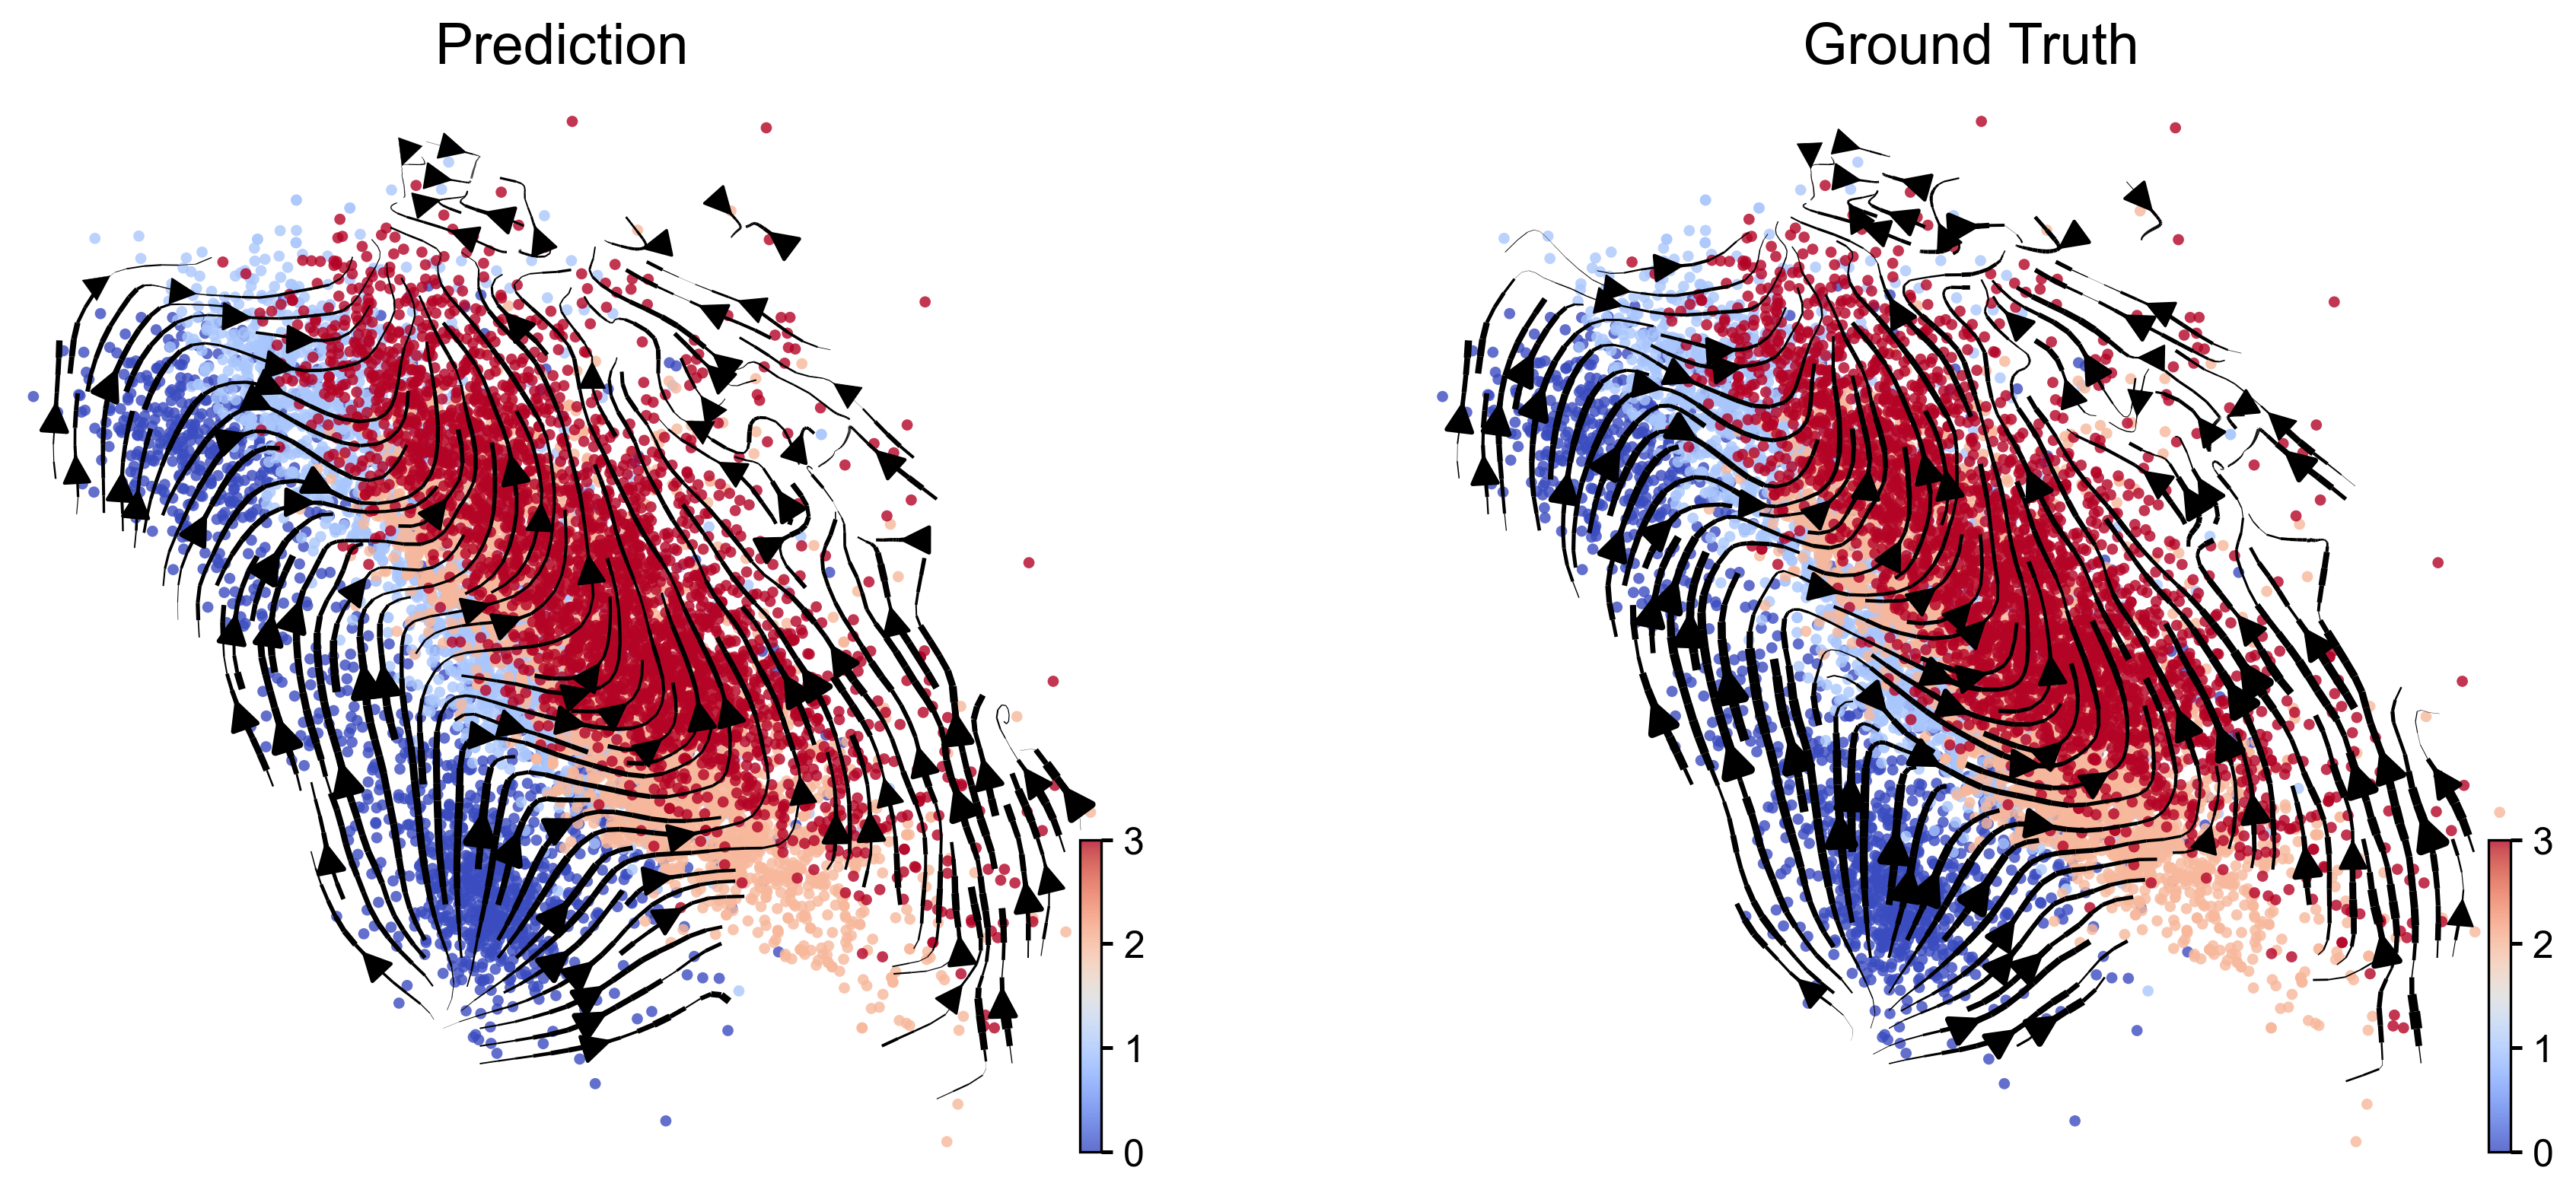

physical


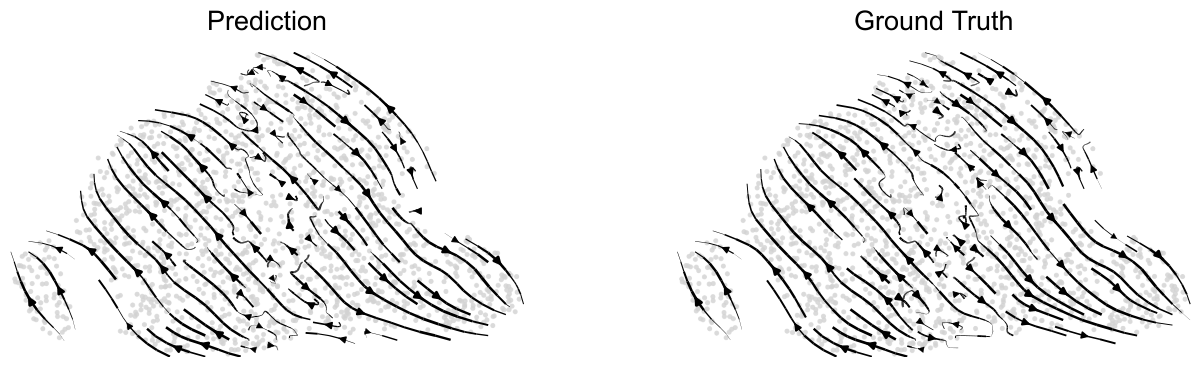

In [3]:
import numpy as np
from reproduction.agist.inputs import evaluate_velocity
from reproduction.agist.main_figure import calculate_velocity_display, draw_velocity_display

observed, predicted = evaluate_velocity(
    agist_root / "mouse_brain_simulation.csv", agist_root / "config.yaml",
    agist_root / "model", agist_root / "edge_classifier/mouse.pt",
    device=device, seed=42)
np.savez_compressed(output / "model_velocity.npz", **predicted)
velocity_display = calculate_velocity_display(
    observed, predicted, agist_root / "figure_fields/figure_fields.npz",
    output / "velocity_display", n_jobs=4)
velocity_figures = draw_velocity_display(velocity_display, figures)
for space, path in velocity_figures.items():
    print(space)
    show_calculated(path)

## c. Calculate time-zero attention and draw the spatial flow

The c calculation uses all time-zero cells in one graph, not the random
groups used for simulation. It averages the absolute first-layer attention
over eight heads, sums outgoing edges, and forms the original 50×50 flow grid
from the top 5,000 positive edges. Sparse edges avoid storing a dense matrix.
The original `1214` model and the matching generator arrays are included in
the Figure 2 download. The model is evaluated here, rather than loading the
saved prediction matrix.

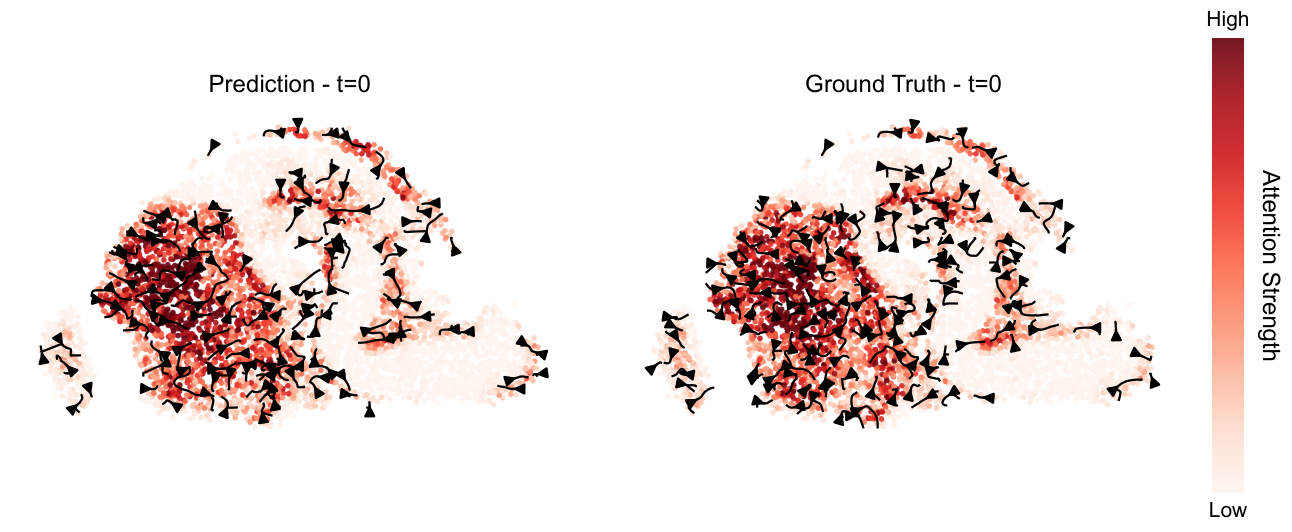

In [4]:
from reproduction.agist.main_figure import (
    evaluate_growth_attention, calculate_attention_display,
    draw_attention_display, draw_growth_correlation,
)

attention_model = figure2_root / "model_1214"
_, attention_edges = evaluate_growth_attention(
    agist_root / "mouse_brain_simulation.csv", attention_model / "params.yml",
    attention_model, figure2_root / "edge_classifier/mouse.pt",
    output / "original_attention", device=device)
coordinates_t0 = observed.loc[observed["samples"].eq(0), ["x1", "x2"]].to_numpy()
predicted_attention = calculate_attention_display(attention_edges, coordinates_t0)
np.savez_compressed(output / "predicted_attention_display.npz", **predicted_attention)
reference = Path(os.environ.get("CYTOBRIDGE_AGIST_GENERATOR_REFERENCE",
                               figure2_root / "reference"))
truth_attention = calculate_attention_display(
    np.load(reference / "attn_matrix_time0.npy", allow_pickle=False), coordinates_t0)
attention_pdf = draw_attention_display(
    coordinates_t0, predicted_attention, truth_attention, figures)
show_calculated(attention_pdf)

## d. Calculate growth and compare with the generator

Evaluate the released six-stage model on all 31,816 observed cells. Clip each
growth distribution at its 1st and 99th percentiles, scale to 0–1, then
calculate Pearson correlation and the fitted line. The truth and prediction
remain paired in the original CSV row order.

Saving to outputs/main_figure_2_scow_verified/figures/correlation_final_box.pdf...


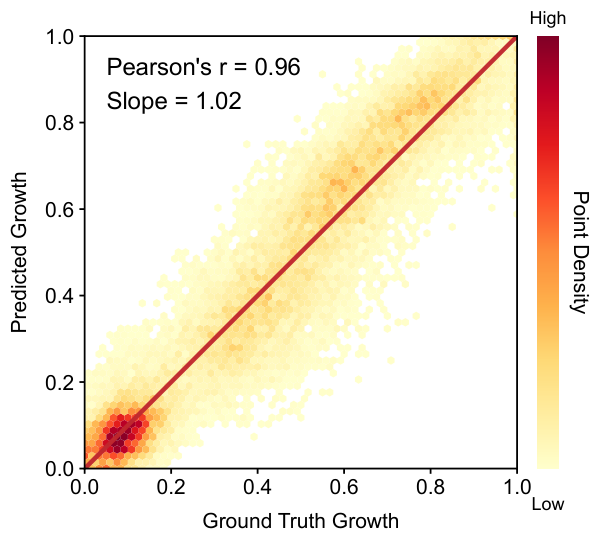

{'pearson_r': 0.9553251682963739,
 'slope': 1.0180585515780884,
 'intercept': -0.0006464862941216176,
 'n': 31816}

In [5]:
growth, _ = evaluate_growth_attention(
    agist_root / "mouse_brain_simulation.csv", agist_root / "config.yaml",
    agist_root / "model", agist_root / "edge_classifier/mouse.pt",
    output / "released_growth", device=device)
growth_pdf, growth_metrics = draw_growth_correlation(
    growth, np.load(reference / "g_values.npy", allow_pickle=False), figures)
show_calculated(growth_pdf)
display(growth_metrics)

## e. Simulate ten independently seeded populations

The checkpoint and time-zero observations remain fixed. The seeds vary the
interaction grouping, Brownian increments and cell birth/loss draws.
The original settings are dt=0.1, sigma=0.03, group size 1,024 and zero
daughter displacement.

To evaluate previously generated populations, set
`CYTOBRIDGE_AGIST_TRAJECTORIES` to their `trajectories` directory.
This reuses trajectories, not distances or a finished figure.

In [6]:
trajectory_override = os.environ.get("CYTOBRIDGE_AGIST_TRAJECTORIES")
distance_override = os.environ.get("CYTOBRIDGE_AGIST_DISTANCES")
if distance_override:
    trajectories = None  # Reuse explicitly selected complete W2 evaluation.
elif trajectory_override:
    trajectories = Path(trajectory_override)
else:
    simulation = output / "simulation"
    run("scripts.run_agist_split_sde_replicates",
        "--config", agist_root / "config.yaml",
        "--checkpoint-dir", agist_root / "model",
        "--edge-predictor", agist_root / "edge_classifier/mouse.pt",
        "--data-csv", agist_root / "mouse_brain_simulation.csv",
        "--output-dir", simulation, "--simulate-only", "--device", device)
    trajectories = simulation / "trajectories"

## e. Calculate the weighted distances in the original coordinate spaces

Read the populations above, calculate W2 at times 1, 2 and 3 in the two
spatial coordinates and all 50 gene coordinates, then summarize the ten
replicates as means and sample standard deviations. This is exact transport
on the full populations and can take tens of minutes on CPU.

For a previously completed calculation, `CYTOBRIDGE_AGIST_DISTANCES` may point
to its distance directory. That explicit choice reuses numeric evaluation
results; leaving it unset runs the calculation below.

In [7]:
if distance_override:
    distances = Path(distance_override)
else:
    distances = output / "distances"
    run("scripts.evaluate_and_plot_agist_w2_replicates",
        "--trajectory-dir", trajectories,
        "--truth-csv", agist_root / "mouse_brain_simulation.csv",
        "--output-dir", distances)

## e. Draw the newly selected distance calculation

The CytoBridge values are read from `distances`. STORIES and stVCR use the
paper's recorded external benchmark values.

,space,time,mean_w2,sd_w2,n,min_w2,max_w2,mean_n_predicted,sd_n_predicted,se_w2,ci95_halfwidth
0,gene,1,1.000585,0.004713,10,0.995648,1.011058,7312.5,33.814034,0.001491,0.003372
1,gene,2,1.179081,0.003420,10,1.174406,1.185135,9429.1,53.463279,0.001081,0.002446
2,gene,3,1.281960,0.003516,10,1.277129,1.288442,10083.0,65.613346,0.001112,0.002515
3,physical,1,0.022481,0.000343,10,0.021966,0.023067,7312.5,33.814034,0.000108,0.000245
4,physical,2,0.026083,0.001093,10,0.025099,0.028882,9429.1,53.463279,0.000346,0.000782
5,physical,3,0.028520,0.001439,10,0.027263,0.031785,10083.0,65.613346,0.000455,0.001029


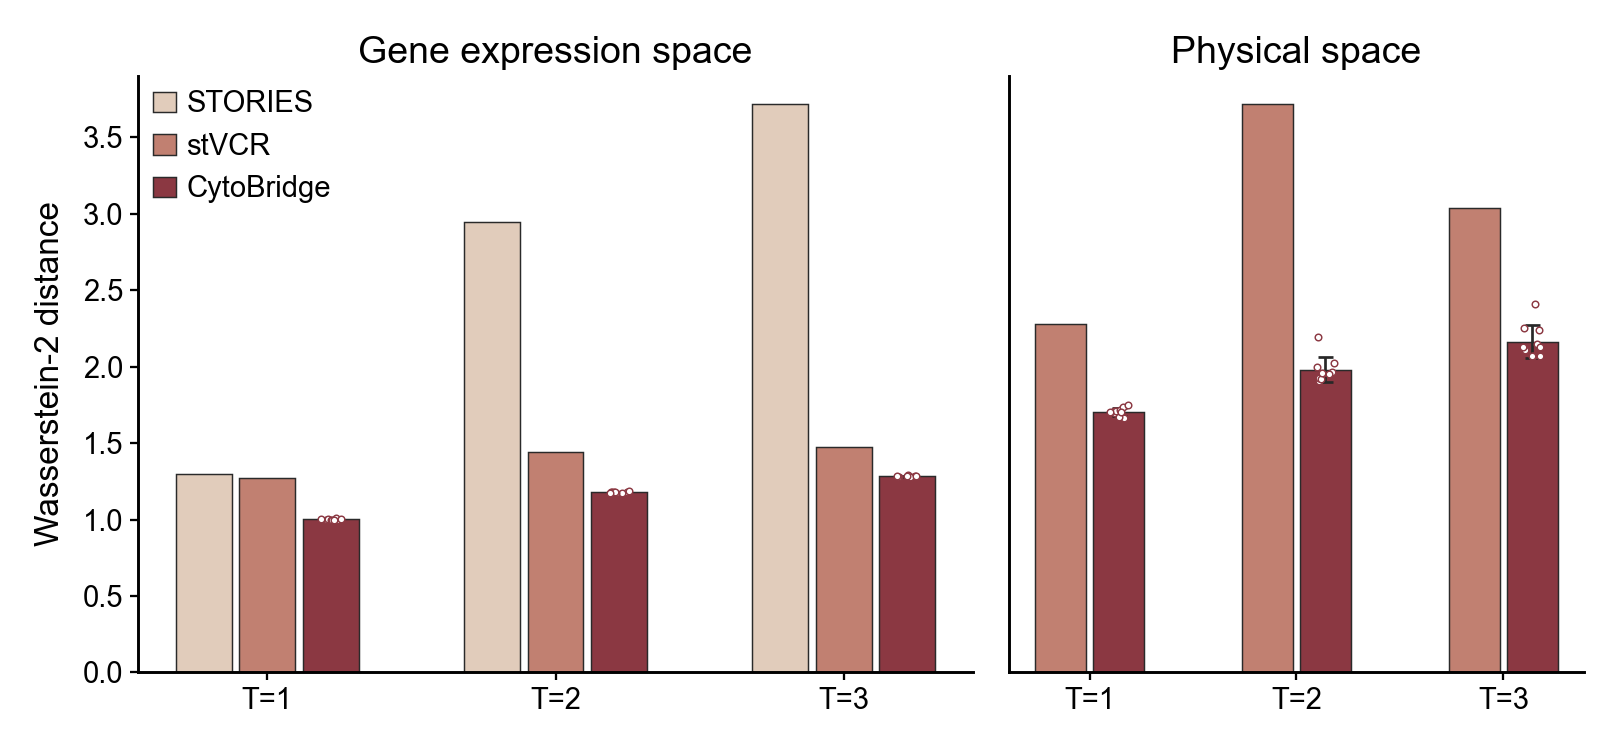

(PosixPath('outputs/main_figure_2_scow_verified/figures/panel_e.pdf'),
 PosixPath('outputs/main_figure_2_scow_verified/figures/panel_e.png'))

In [8]:
from reproduction.agist.inputs import main_figure_2_from_evaluation
from reproduction.agist.main_figure import draw_distance_panels

figure_data = main_figure_2_from_evaluation(distances)
display(figure_data.summary)
pdf, png = draw_distance_panels(figure_data, figures)
display(Image(filename=str(png), width=720))
pdf, png

## Related analysis: attention strength across four time points

The [attention-strength notebook](agist_attention_recovery.ipynb) evaluates
the separate 6,707-cell simulation and its matching model. Its four Spearman
correlations average to 0.77746 (0.78). That statistic is not the correlation
of the T0 maps in panel c, which use the 31,816-cell experiment.